In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../python')
import threepoint

# Simulation-based covariance

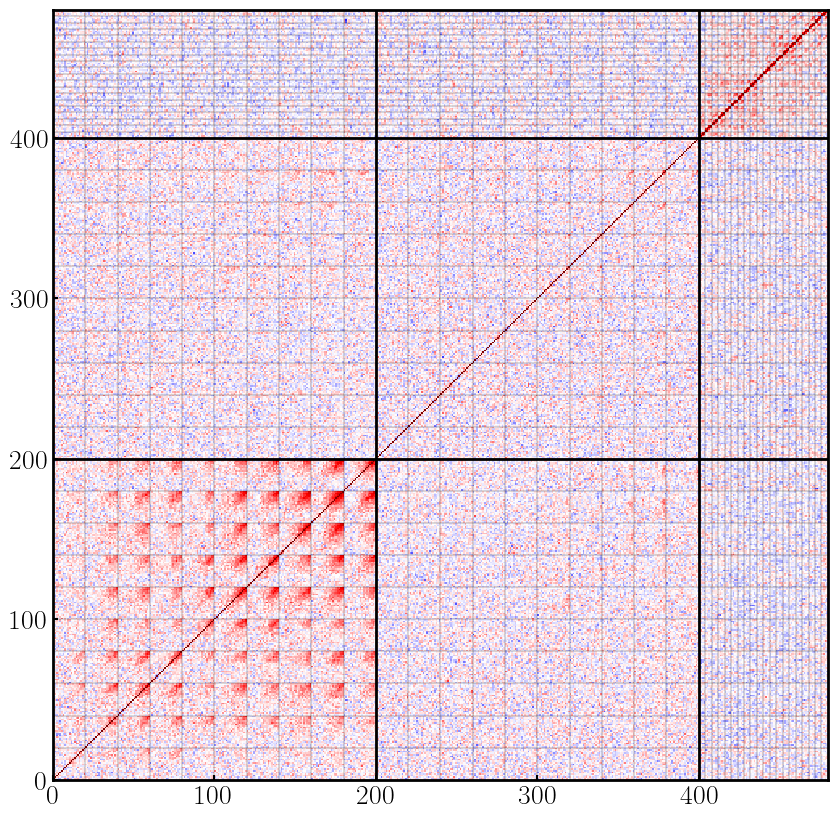

In [48]:
cov = np.loadtxt('../data/covariance/cov_xip_xim_map3.dat')
_ = np.diag(cov)
rcc = cov/np.outer(_, _)**0.5
# Plotd
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1)
for v in [200, 400]:
    ax.axhline(v, color='k', lw=2)
    ax.axvline(v, color='k', lw=2)
for v in range(20):
    ax.axhline(v*20, color='k', lw=0.2)
    ax.axvline(v*20, color='k', lw=0.2)
for v in range(20):
    ax.axhline(v*4+400, color='k', lw=0.2)
    ax.axvline(v*4+400, color='k', lw=0.2)
plt.savefig('../plots/covariance_simbased_2pt_map3.png', bbox_inches='tight')
plt.show()

## map3 only covariance

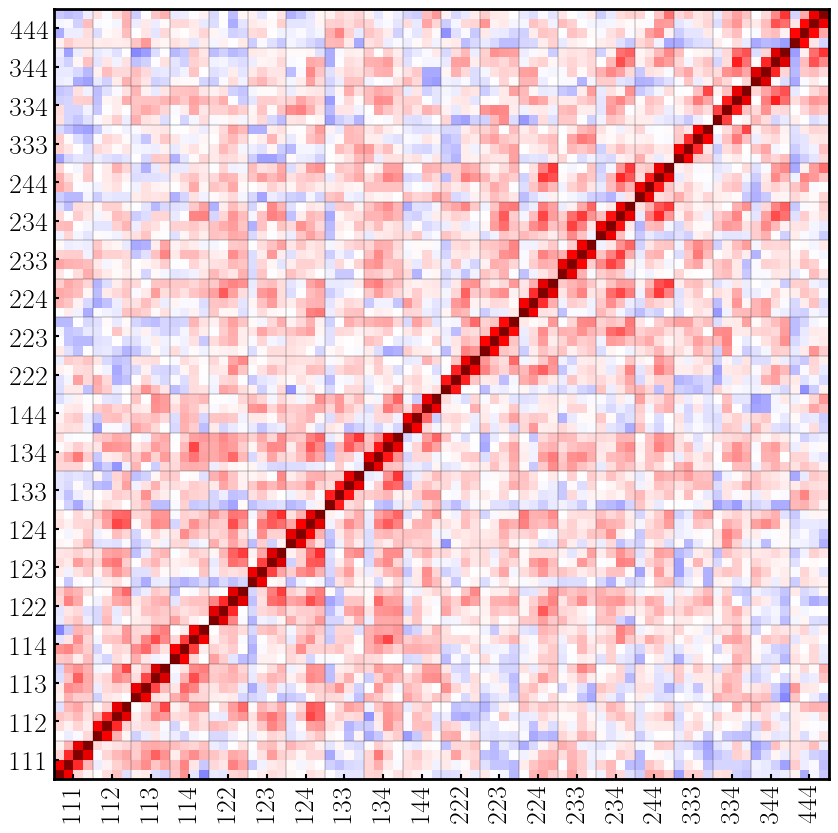

In [50]:
cov = np.loadtxt('../data/covariance/cov_xip_xim_map3.dat')[400:,400:]
_ = np.diag(cov)
rcc = cov/np.outer(_, _)**0.5
# plot
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1)
for v in range(20):
    ax.axhline(v*4, color='k', lw=0.2)
    ax.axvline(v*4, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        for k in range(j, 4):
            labels.append(f'{i+1}{j+1}{k+1}')
ax.set_xticks(4*np.arange(20)+2, labels, rotation=90)
ax.set_yticks(4*np.arange(20)+2, labels)
fig.savefig('../plots/covariance_simbased_map3.png', bbox_inches='tight')
plt.show()

## analytic covariance for 2pt

In [51]:
from astropy.io import fits
hdul = fits.open('../data/dv/sim_2pt-NLA-cosmoDESY3.fits')
cov = hdul['COVMAT'].data[:400,:400]
_ = np.diag(cov)
rcc = cov/np.outer(_, _)**0.5

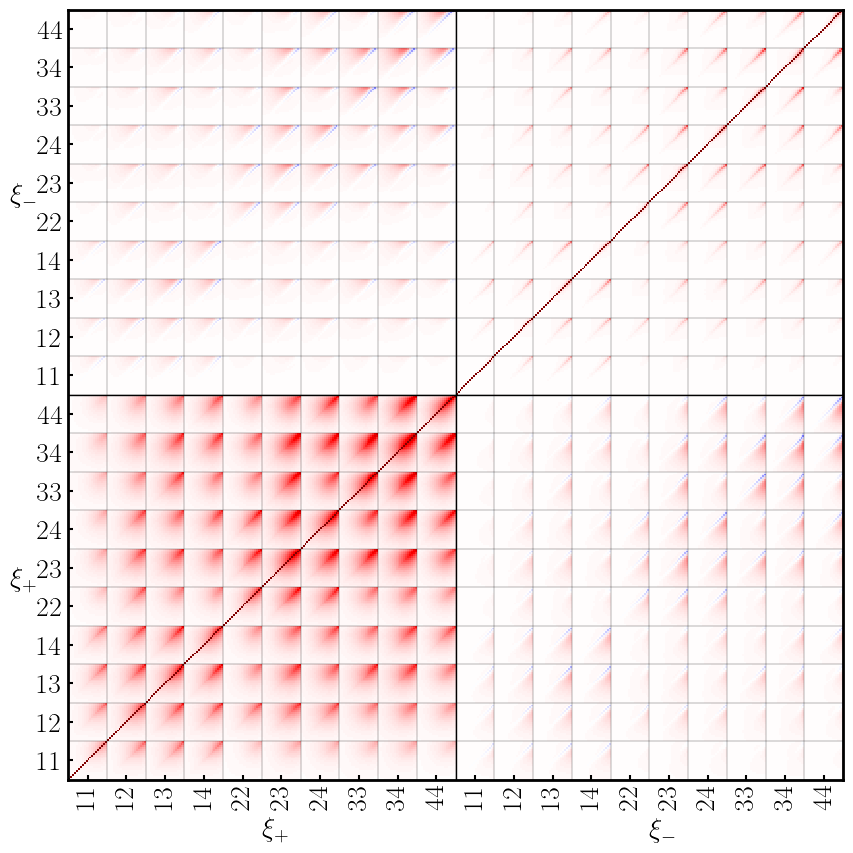

In [52]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1)
for v in [200, 400]:
    ax.axhline(v, color='k', lw=1)
    ax.axvline(v, color='k', lw=1)
for v in range(20):
    ax.axhline(v*20, color='k', lw=0.2)
    ax.axvline(v*20, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        labels.append(f'{i+1}{j+1}')
labels = labels + labels
ax.set_xticks(20*np.arange(20)+10, labels, rotation=90)
ax.set_yticks(20*np.arange(20)+10, labels)
# xipm
ax.text(100, -30, r'$\xi_+$', fontsize=20)
ax.text(300, -30, r'$\xi_-$', fontsize=20)
ax.text(-30, 100, r'$\xi_+$', fontsize=20)
ax.text(-30, 300, r'$\xi_-$', fontsize=20)
fig.savefig('../plots/covariance_analytic_2pt.png', bbox_inches='tight')
plt.show()

In [53]:
# sim-based
cov = np.loadtxt('../data/covariance/cov_xip_xim_map3.dat')[:400,:400]
_ = np.diag(cov)
rcc_sim = cov/np.outer(_, _)**0.5
# ana-based
hdul = fits.open('../data/dv/sim_2pt-NLA-cosmoDESY3.fits')
cov = hdul['COVMAT'].data[:400,:400]
_ = np.diag(cov)
rcc_ana = cov/np.outer(_, _)**0.5

# Hetero
rcc = rcc_sim.copy()
_ = np.arange(rcc_sim.shape[0])
_ = _[None,:] < _[:,None]
rcc[_] = rcc_ana[_]

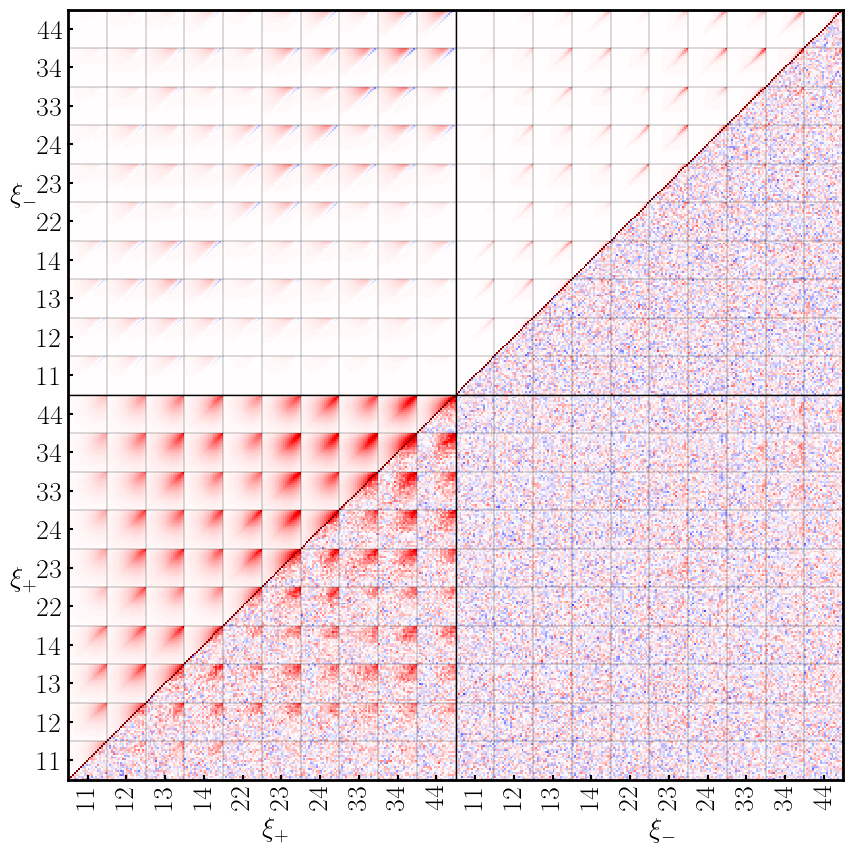

In [54]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.pcolormesh(rcc, vmin=-1, vmax=1)
for v in [200, 400]:
    ax.axhline(v, color='k', lw=1)
    ax.axvline(v, color='k', lw=1)
for v in range(20):
    ax.axhline(v*20, color='k', lw=0.2)
    ax.axvline(v*20, color='k', lw=0.2)
# label
labels = []
for i in range(4):
    for j in range(i, 4):
        labels.append(f'{i+1}{j+1}')
labels = labels + labels
ax.set_xticks(20*np.arange(20)+10, labels, rotation=90)
ax.set_yticks(20*np.arange(20)+10, labels)
# xipm
ax.text(100, -30, r'$\xi_+$', fontsize=20)
ax.text(300, -30, r'$\xi_-$', fontsize=20)
ax.text(-30, 100, r'$\xi_+$', fontsize=20)
ax.text(-30, 300, r'$\xi_-$', fontsize=20)
fig.savefig('../plots/covariance_anasim_2pt.png', bbox_inches='tight')
plt.show()